In [1]:
%%bash
pip3 install gymnasium[classic_control]

In [2]:
import gymnasium as gym
import math
import random
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple,deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

env = gym.make("CartPole-v1")

In [16]:
# set up matplotlib

is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
  from IPython import display

plt.ion()

In [17]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

In [18]:
seed = 123
random.seed(seed)
torch.manual_seed(seed)
env.reset(seed=seed)
env.action_space.seed(seed)
env.observation_space.seed(seed)
if torch.cuda.is_available():
  torch.cuda.manual_seed(seed)

Replay Memory

Using experience replay memory for training DQN. It stores the transitions that the agent observes, allowing to reuse this data later. By sampling from it randomly, the transitions that build up a batch are decorrelated. It has been shown that this greatly stabilizes and improves the DQN training procedure.

In [19]:
Transition = namedtuple('Transition',('state','action','next_state','reward'))

class ReplayMemory(object):
  def __init__(self,capacity):
    self.memory = deque([],maxlen=capacity)

  def push(self,*args):
    """Save a transition"""
    self.memory.append(Transition(*args))

  def sample(self,batch_size):
    return random.sample(self.memory,batch_size)

  def __len__(self):
    return len(self.memory)


Our environment is deterministic, so all equations presented here are also formulated deterministically for the sake of simplicity. In the reinforcement learning literature, they would also contain expectations over stochastic transitions in the environment.

Our aim will be to train a policy that tries to maximize the discounted, cumulative reward $R_{t_0} = \sum_{t=t_0}^{\infty} \gamma^{t-t_0} r_t$, where $R_{t_0}$ is also known as the return. The discount, $\gamma$, should be a constant between $0$ and $1$ that ensures the sum converges. A lower $\gamma$ makes rewards from the uncertain far future less important for our agent than the ones in the near future that it can be fairly confident about. It also encourages agents to collect reward closer in time than equivalent rewards that are temporally far away in the future.

The main idea behind Q-learning is that if we had a function $Q^*: State \times Action \rightarrow \mathbb{R}$, that could tell us what our return would be, if we were to take an action in a given state, then we could easily construct a policy that maximizes our rewards:

$\pi^*(s) = \underset{a}{\arg\max} Q^*(s,a)$

However, we don’t know everything about the world, so we don’t have access to $Q^*$. But, since neural networks are universal function approximators, we can simply create one and train it to resemble $Q^*$.

For our training update rule, we’ll use a fact that every $Q$ function for some policy obeys the Bellman equation:

$Q^\pi(s,a) = r + \gamma Q^\pi(s', \pi(s'))$

The difference between the two sides of the equality is known as the temporal difference error, $\delta$:

$\delta = Q(s,a) - (r + \gamma \underset{a'}{\max} Q(s',a))$

To minimize this error, we will use the Huber loss. The Huber loss acts like the mean squared error when the error is small, but like the mean absolute error when the error is large - this makes it more robust to outliers when the estimates of $Q$ are very noisy. We calculate this over a batch of transitions, $B$, sampled from the replay memory:

$L = \frac{1}{|B|} \sum_{(s,a,s',r) \in B} L(\delta)$

where
$L(\delta) = \begin{cases} \frac{1}{2}\delta^2 & \text{for } |\delta| \le 1, \\ |\delta| - \frac{1}{2} & \text{otherwise.} \end{cases}$

### Q-network

In [20]:
class DQN(nn.Module):

  def __init__(self,n_observations,n_actions):
    super(DQN,self).__init__()
    self.layer1 = nn.Linear(n_observations,128)
    self.layer2 = nn.Linear(128,128)
    self.layer3 = nn.Linear(128,n_actions)

  def forward(self,x):
    x = F.relu(self.layer1(x))
    x = F.relu(self.layer2(x))
    return self.layer3(x)


In [21]:
# BATCH_SIZE is the number of transitions sampled from the replay buffer
# GAMMA is the discount factor as mentioned in the previous section
# EPS_START is the starting value of epsilon
# EPS_END is the final value of epsilon
# EPS_DECAY controls the rate of exponential decay of epsilon, higher means a slower decay
# TAU is the update rate of the target network
# LR is the learning rate of the ``AdamW`` optimizer

BATCH_SIZE = 128
GAMMA = 0.99
EPS_START = 0.9
EPS_END = 0.01
EPS_DECAY = 2500
TAU = 0.005
LR = 3e-4

n_actions = env.action_space.n
state,info = env.reset()
n_observations = len(state)

policy_net = DQN(n_observations,n_actions).to(device)
target_net = DQN(n_observations,n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.AdamW(policy_net.parameters(),lr=LR,amsgrad=True)
memory = ReplayMemory(10000)

steps_done = 0

def select_action(state):
  global steps_done
  sample = random.random()

  eps_threshold = EPS_END + (EPS_START - EPS_END) * \
    math.exp(-1. * steps_done / EPS_DECAY)
  steps_done += 1
  if sample > eps_threshold:
    with torch.no_grad():
      return policy_net(state).max(1).indices.view(1,1)
  else:
    return torch.tensor([[env.action_space.sample()]],device=device,dtype=torch.long)


In [22]:
episode_durations = []

def plot_durations(show_result=False):
  plt.figure(1)
  durations_t = torch.tensor(episode_durations,dtype=torch.float)
  if show_result:
    plt.title("Result")
  else:
    plt.clf()
    plt.title("Training")
  plt.xlabel("Episode")
  plt.ylabel("Duration")
  plt.plot(durations_t.numpy())

  if len(durations_t) >= 100:
    means = durations_t.unfold(0,100,1).mean(1).view(-1)
    means = torch.cat((torch.zeros(99),means))
    plt.plot(means.numpy())

  plt.pause(0.001)  # pause a bit so that plots are updated
  if is_ipython:
      if not show_result:
          display.display(plt.gcf())
          display.clear_output(wait=True)
      else:
          display.display(plt.gcf())

In [23]:
## Training loop

def optimize_model():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    # Transpose the batch (see https://stackoverflow.com/a/19343/3343043 for
    # detailed explanation). This converts batch-array of Transitions
    # to Transition of batch-arrays.
    batch = Transition(*zip(*transitions))

    # Compute a mask of non-final states and concatenate the batch elements
    # (a final state would've been the one after which simulation ended)
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                                if s is not None])
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    # Compute Q(s_t, a) - the model computes Q(s_t), then we select the
    # columns of actions taken. These are the actions which would've been taken
    # for each batch state according to policy_net
    state_action_values = policy_net(state_batch).gather(1, action_batch)

    # Compute V(s_{t+1}) for all next states.
    # Expected values of actions for non_final_next_states are computed based
    # on the "older" target_net; selecting their best reward with max(1).values
    # This is merged based on the mask, such that we'll have either the expected
    # state value or 0 in case the state was final.
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values
    # Compute the expected Q values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # Compute Huber loss
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    # Optimize the model
    optimizer.zero_grad()
    loss.backward()
    # In-place gradient clipping
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

Complete


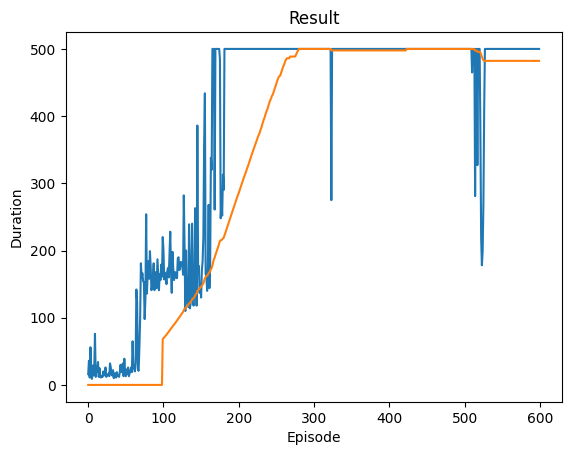

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [24]:
if torch.cuda.is_available() or torch.backends.mps.is_available():
    num_episodes = 600
else:
    num_episodes = 50

for i_episode in range(num_episodes):
    # Initialize the environment and get its state
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    for t in count():
        action = select_action(state)
        observation, reward, terminated, truncated, _ = env.step(action.item())
        reward = torch.tensor([reward], device=device)
        done = terminated or truncated

        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

        # Store the transition in memory
        memory.push(state, action, next_state, reward)

        # Move to the next state
        state = next_state

        # Perform one step of the optimization (on the policy network)
        optimize_model()

        # Soft update of the target network's weights
        # θ′ ← τ θ + (1 −τ )θ′
        target_net_state_dict = target_net.state_dict()
        policy_net_state_dict = policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
        target_net.load_state_dict(target_net_state_dict)

        if done:
            episode_durations.append(t + 1)
            plot_durations()
            break

print('Complete')
plot_durations(show_result=True)
plt.ioff()
plt.show()

In [25]:
!sudo apt-get install -y xvfb
!pip install -q pyvirtualdisplay

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.15).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [26]:
from pyvirtualdisplay import Display
import matplotlib.pyplot as plt
import base64
from IPython.display import HTML
import gymnasium as gym
import imageio
import torch

# Start a virtual display (necessary for Colab to render)
display = Display(visible=0, size=(1400, 900))
display.start()

# Create new environment with video rendering
video_env = gym.make("CartPole-v1", render_mode="rgb_array")
video_frames = []

# Reset env
state, _ = video_env.reset()
state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

for _ in range(500):
    with torch.no_grad():
        action = policy_net(state).max(1).indices.view(1, 1)

    # Step in the video_env
    next_obs, _, terminated, truncated, _ = video_env.step(action.item())
    video_frames.append(video_env.render())  #  Save the frame!

    if terminated or truncated:
        break

    # Update state
    state = torch.tensor(next_obs, dtype=torch.float32, device=device).unsqueeze(0)

video_env.close()

# Save the video
video_path = "/content/cartpole.mp4"
imageio.mimsave(video_path, video_frames, fps=30)

# Display the video
def display_video(filename):
    video = open(filename, "rb").read()
    encoded = base64.b64encode(video).decode("ascii")
    return HTML(f'''

    ''')

display_video(video_path)